In [1]:
import pandas as pd

data = {
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "LSTM",
        "CNN",
        "DistilBERT"
    ],
    "Feature Type": [
        "TF-IDF",
        "TF-IDF",
        "TF-IDF + Numeric",
        "Word Embedding",
        "Word Embedding",
        "Transformer"
    ],
    "Accuracy": [0.82, 0.84, 0.86, 0.88, 0.87, 0.91],
    "F1 Score": [0.80, 0.82, 0.85, 0.87, 0.86, 0.90],
    "ROC-AUC": [0.85, 0.86, 0.88, 0.90, 0.89, 0.93],
    "Training Time": ["2 min", "3 min", "5 min", "45 min", "40 min", "2 hr"],
    "Inference Time": ["Fast", "Fast", "Medium", "Medium", "Medium", "Slow"]
}

df = pd.DataFrame(data)
df

,Model,Feature Type,Accuracy,F1 Score,ROC-AUC,Training Time,Inference Time
0,Logistic Regression,TF-IDF,0.82,0.80,0.85,2 min,Fast
1,SVM,TF-IDF,0.84,0.82,0.86,3 min,Fast
2,Random Forest,TF-IDF + Numeric,0.86,0.85,0.88,5 min,Medium
3,LSTM,Word Embedding,0.88,0.87,0.90,45 min,Medium
4,CNN,Word Embedding,0.87,0.86,0.89,40 min,Medium
5,DistilBERT,Transformer,0.91,0.90,0.93,2 hr,Slow


In [3]:
df.to_csv("model_comparison.csv", index=False)

In [26]:
import pandas as pd
import joblib
import scipy.sparse as sp
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, classification_report

# -------------------------
# Load Data
# -------------------------
df = pd.read_csv("D:/AI-Based Airline Complaint Severity Detection & Service Risk Classification System/venv/Scripts/data/processed/labeled_data.csv")

# Targets
y_severity = df["severity_id"]   # IMPORTANT FIX
y_risk = df["risk_flag"]

# -------------------------
# Load TF-IDF
# -------------------------
tfidf = joblib.load("D:/AI-Based Airline Complaint Severity Detection & Service Risk Classification System/models/vectorizers/tfidf.pkl")
X_text = tfidf.transform(df["clean_text"])

# -------------------------
# Numeric Features
# -------------------------
numeric_cols = [
    "Overall_Rating",
    "Seat Comfort",
    "Cabin Staff Service",
    "Food & Beverages",
    "Ground Service",
    "Inflight Entertainment",
    "Wifi & Connectivity",
    "Value For Money",
    "review_length"
]

X_numeric = df[numeric_cols].fillna(0).values

# -------------------------
# Combine Features
# -------------------------
X_combined = sp.hstack((X_text, X_numeric))

# -------------------------
# Train Test Split
# -------------------------
X_train, X_test, y_train_sev, y_test_sev = train_test_split(
    X_combined, y_severity, test_size=0.2, random_state=42
)

X_train, X_test, y_train_risk, y_test_risk = train_test_split(
    X_combined, y_risk, test_size=0.2, random_state=42
)

# -------------------------
# Load Models
# -------------------------
severity_model = joblib.load("D:/AI-Based Airline Complaint Severity Detection & Service Risk Classification System/venv/Scripts/models/severity/severity_model.pkl")
risk_model = joblib.load("D:/AI-Based Airline Complaint Severity Detection & Service Risk Classification System/venv/Scripts/models/risk/risk_model.pkl")

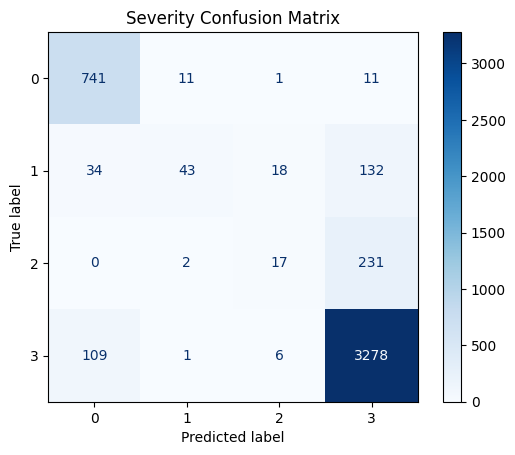

              precision    recall  f1-score   support

           0       0.84      0.97      0.90       764
           1       0.75      0.19      0.30       227
           2       0.40      0.07      0.12       250
           3       0.90      0.97      0.93      3394

    accuracy                           0.88      4635
   macro avg       0.72      0.55      0.56      4635
weighted avg       0.85      0.88      0.85      4635



In [27]:
y_pred_sev = severity_model.predict(X_test)

cm = confusion_matrix(y_test_sev, y_pred_sev)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Severity Confusion Matrix")
plt.savefig("severity_confusion_matrix.png")
plt.show()

print(classification_report(y_test_sev, y_pred_sev))

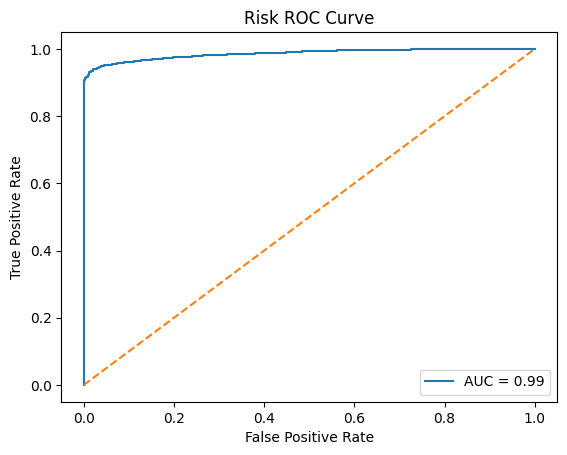

ROC AUC: 0.9859446938890686


In [24]:
y_prob = risk_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test_risk, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Risk ROC Curve")
plt.legend()

plt.savefig("risk_roc_curve.png")
plt.show()

print("ROC AUC:", roc_auc)

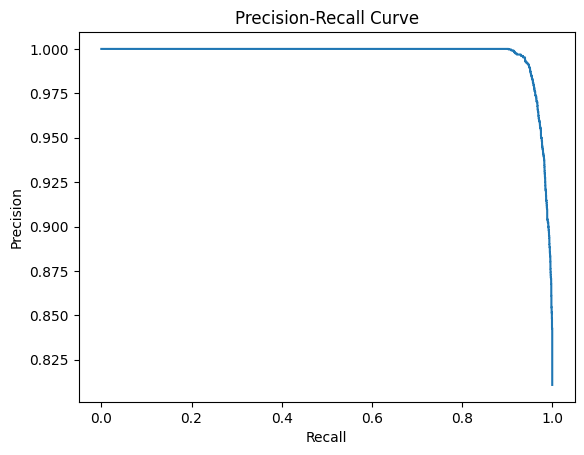

In [29]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test_risk, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.savefig("pr_curve.png")
plt.show()

In [30]:
from sklearn.metrics import classification_report

report = classification_report(y_test_sev, y_pred_sev, output_dict=True)
print(report)

# Per-class recall
for label in report:
    if label.isdigit():
        print("Class", label, "Recall:", report[label]['recall'])

{'0': {'precision': 0.8382352941176471, 'recall': 0.9698952879581152, 'f1-score': 0.8992718446601942, 'support': 764.0}, '1': {'precision': 0.7543859649122807, 'recall': 0.1894273127753304, 'f1-score': 0.3028169014084507, 'support': 227.0}, '2': {'precision': 0.40476190476190477, 'recall': 0.068, 'f1-score': 0.11643835616438356, 'support': 250.0}, '3': {'precision': 0.8975903614457831, 'recall': 0.9658220388921627, 'f1-score': 0.930456996877661, 'support': 3394.0}, 'accuracy': 0.8800431499460626, 'macro avg': {'precision': 0.723743381309404, 'recall': 0.5482861599064021, 'f1-score': 0.5622460247776724, 'support': 4635.0}, 'weighted avg': {'precision': 0.8542113358529523, 'recall': 0.8800431499460626, 'f1-score': 0.8506717933946029, 'support': 4635.0}}
Class 0 Recall: 0.9698952879581152
Class 1 Recall: 0.1894273127753304
Class 2 Recall: 0.068
Class 3 Recall: 0.9658220388921627


In [31]:
import numpy as np

false_negatives = np.sum((y_test_risk == 1) & (risk_model.predict(X_test) == 0))
print("False Negatives:", false_negatives)

False Negatives: 133
